# Forecasting SPX Range Regimes

This notebook contains the code for generating the artifacts used to evaluate the economic impact of regime forecasting on a 1DTE SPX iron condor strategy. It loads the the trades made by the baseline strategy.

It includes model predictions, trade filtering logic, and performance analysis such as equity curves, drawdowns, classification metrics, and conditional PnL by probability buckets.

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from qc_utils import load_trades

## Data

In [2]:
INITIAL_CAPITAL = 50_000
REGIME_THRESHOLD = 51.698
SKIP_PROB_THRESHOLD = 0.4

trades = load_trades("data/baseline_v1_trades_02_13_2026.csv")
trades['date'] = trades['entry_time'].dt.date
trades['fees'] = 5

# NOTE: SPX daily bars
spx_day = pd.read_csv("data/SPX_day_1980-01-01_2026-03-24.csv", header=0)
spx_day['date'] = pd.to_datetime(spx_day['datetime']).dt.date
spx_day["range"] = spx_day["high"] - spx_day["low"]
spx_day["ret"] = np.log(spx_day["close"] / spx_day["close"].shift(1))
spx_day["5d_avg_range"] = spx_day["range"].shift(1).rolling(5).mean()
spx_day["prior_abs_ret"] = spx_day["ret"].shift(1).abs()
spx_day["gap_mag"] = ((spx_day["open"] - spx_day["close"].shift(1)) / spx_day["close"].shift(1)).abs()
spx_day["regime_target"] = spx_day["range"].shift(-1) >= REGIME_THRESHOLD

# NOTE: vix daily bars
vix_day = pd.read_csv("data/VIX_day_1980-01-01_2026-03-24.csv", header=0)
vix_day['date'] = pd.to_datetime(vix_day['datetime']).dt.date
vix_day["prior_vix_close"] = vix_day["close"].shift(1)

# NOTE: vix9d daily bars
vix9d_day = pd.read_csv("data/VIX9D_day_2000-01-01_2026-03-24.csv", header=0)
vix9d_day['date'] = pd.to_datetime(vix9d_day['datetime']).dt.date
vix9d_day["prior_vix9d_close"] = vix9d_day["close"].shift(1)

# NOTE: combined vix feature set
vix_ft = vix_day[["date", "prior_vix_close"]].merge(
    vix9d_day[["date", "prior_vix9d_close"]],
    on="date",
    how="inner",
)
vix_ft["prior_slope"] = vix_ft["prior_vix9d_close"] - vix_ft["prior_vix_close"]

In [3]:
spx_day['regime_target'].value_counts()

regime_target
False    10860
True       791
Name: count, dtype: int64

## Build Regime Range Model

In [76]:
model_ft_cols = ["prior_slope", "5d_avg_range", "prior_abs_ret", "gap_mag"]
model_fts = spx_day[
        [
            "date",
            "regime_target",
            "5d_avg_range",
            "prior_abs_ret",
            "gap_mag",
        ]
    ].merge(
        vix_ft[["date", "prior_slope"]],
        on="date",
        how="left",
    )
model_fts = model_fts.dropna().set_index("date")
model_fts.index = pd.to_datetime(model_fts.index)

In [77]:
train = model_fts.loc["2022-04-01":"2023-12-31"].copy()
test = model_fts.loc["2024-01-01":"2025-12-31"].copy()

x_train = train[model_ft_cols]
y_train = train["regime_target"].astype(int)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000)
model.fit(x_train_scaled, y_train)

scaled_weights = model.coef_[0]
means = scaler.mean_
scales = scaler.scale_

raw_weights = scaled_weights / scales

LOGIT_INTERCEPT = float(model.intercept_[0] - np.sum(scaled_weights * means / scales))
LOGIT_WEIGHTS = {
    name: float(weight)
    for name, weight in zip(model_ft_cols, raw_weights, strict=True)
}
print(LOGIT_INTERCEPT)
print(LOGIT_WEIGHTS)

-3.936351272627037
{'prior_slope': 0.1348168333597267, '5d_avg_range': 0.062350353138509736, 'prior_abs_ret': 35.231011799516885, 'gap_mag': 39.691725199430685}


## Regime Filter Test

In [78]:
start_date = dt.date(2024,1,1) # NOTE: start date for test dataset
end_date = trades["date"].max()

spx_day = spx_day[(spx_day["date"] >= start_date) & (spx_day["date"] <= end_date)].copy()
vix_ft = vix_ft[(vix_ft["date"] >= start_date) & (vix_ft["date"] <= end_date)].copy()
vix9d_day = vix9d_day[(vix9d_day["date"] >= start_date) & (vix9d_day["date"] <= end_date)].copy()

fts = spx_day.merge(vix_ft, on="date", how="inner")
trade_features = trades.merge(fts, on="date", how="left")

logit = (
    LOGIT_INTERCEPT
    + LOGIT_WEIGHTS["prior_slope"] * trade_features["prior_slope"]
    + LOGIT_WEIGHTS["5d_avg_range"] * trade_features["5d_avg_range"]
    + LOGIT_WEIGHTS["prior_abs_ret"] * trade_features["prior_abs_ret"]
    + LOGIT_WEIGHTS["gap_mag"] * trade_features["gap_mag"]
)
trade_features
trade_features["regime_prob"] = 1.0 / (1.0 + np.exp(-logit))
trade_features["skip_trade"] = trade_features["regime_prob"] >= SKIP_PROB_THRESHOLD
trade_features["keep_trade"] = ~trade_features["skip_trade"]

valid_trades = trade_features.dropna(subset=["regime_prob"]).copy()
filtered_trades = trade_features.dropna().loc[lambda x: x["keep_trade"]].sort_values("entry_time").reset_index(drop=True)

print("All trades:", len(valid_trades))
print("Kept trades:", len(filtered_trades))
print("Skipped trades:", len(valid_trades) - len(filtered_trades))

print("Baseline final equity (PnL):", INITIAL_CAPITAL + valid_trades["pnl"].sum())
print("Baseline final equity (Total PnL):", INITIAL_CAPITAL + valid_trades["total_pnl"].sum())
print("Filtered final equity (PnL):", INITIAL_CAPITAL + filtered_trades["pnl"].sum())
print("Filtered final equity (Total PnL):", INITIAL_CAPITAL + filtered_trades["total_pnl"].sum())

All trades: 388
Kept trades: 225
Skipped trades: 163
Baseline final equity (PnL): 40040
Baseline final equity (Total PnL): 36936
Filtered final equity (PnL): 50530
Filtered final equity (Total PnL): 48730


## Equity & Drawdown

In [79]:
def plot_probability_distribution(trade_features: pd.DataFrame) -> None:
    plot_df = trade_features.dropna(subset=["regime_prob"]).copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(plot_df["regime_prob"], bins=30, alpha=0.8, color="tab:blue")
    axes[0].axvline(SKIP_PROB_THRESHOLD, color="red", linestyle="--", label="Skip threshold")
    axes[0].set_title("Regime Probability Distribution")
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_ylabel("Trade Count")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    kept = plot_df.loc[~plot_df["skip_trade"]]
    skipped = plot_df.loc[plot_df["skip_trade"]]

    axes[1].scatter(
        kept["entry_time"],
        kept["regime_prob"],
        s=20,
        alpha=0.7,
        label="Kept",
        color="tab:blue",
    )
    axes[1].scatter(
        skipped["entry_time"],
        skipped["regime_prob"],
        s=28,
        alpha=0.85,
        label="Skipped",
        color="tab:red",
    )
    axes[1].axhline(SKIP_PROB_THRESHOLD, color="red", linestyle="--")
    axes[1].set_title("Predicted Probability by Trade Date")
    axes[1].set_xlabel("Entry Time")
    axes[1].set_ylabel("Predicted Probability")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_equity_and_drawdown(
    filtered_curve: pd.DataFrame,
    baseline_curve: pd.DataFrame,
    initial_capital: float = INITIAL_CAPITAL,
) -> pd.DataFrame:
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )
    ax_eq, ax_dd = axes

    ax_eq.plot(
        baseline_curve["entry_time"],
        baseline_curve["equity_pnl"],
        label="Baseline Equity (PnL)",
        alpha=0.35,
        linestyle="--",
        color="tab:blue",
    )
    ax_eq.plot(
        baseline_curve["entry_time"],
        baseline_curve["equity_total_pnl"],
        label="Baseline Equity (Total PnL incl fees)",
        alpha=0.35,
        linestyle="--",
        color="tab:orange",
    )

    ax_eq.plot(
        filtered_curve["entry_time"],
        filtered_curve["equity_pnl"],
        label="Filtered Equity (PnL)",
        linewidth=2,
        color="tab:blue",
    )
    ax_eq.plot(
        filtered_curve["entry_time"],
        filtered_curve["equity_total_pnl"],
        label="Filtered Equity (Total PnL incl fees)",
        linewidth=2,
        color="tab:orange",
    )
    ax_eq.axhline(initial_capital, color="gray", linestyle=":", alpha=0.7)
    ax_eq.set_title("Equity Curve")
    ax_eq.set_ylabel("Portfolio Value")
    ax_eq.legend()
    ax_eq.grid(True, alpha=0.3)


    ax_dd.plot(
        baseline_curve["entry_time"],
        baseline_curve["drawdown_pnl"],
        alpha=0.35,
        linestyle="--",
        color="tab:blue",
    )
    ax_dd.plot(
        baseline_curve["entry_time"],
        baseline_curve["drawdown_total_pnl"],
        alpha=0.35,
        linestyle="--",
        color="tab:orange",
    )

    ax_dd.plot(
        filtered_curve["entry_time"],
        filtered_curve["drawdown_pnl"],
        label="Filtered Drawdown (PnL)",
        linewidth=2,
        color="tab:blue",
    )
    ax_dd.plot(
        filtered_curve["entry_time"],
        filtered_curve["drawdown_total_pnl"],
        label="Filtered Drawdown (Total PnL incl fees)",
        linewidth=2,
        color="tab:orange",
    )
    ax_dd.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax_dd.set_title("Drawdown")
    ax_dd.set_ylabel("Drawdown")
    ax_dd.set_xlabel("Entry Time")
    ax_dd.legend()
    ax_dd.grid(True, alpha=0.3)

    return fig, axes

In [80]:
filtered_curve = filtered_trades.copy().sort_values("entry_time").reset_index(drop=True)
filtered_curve["equity_pnl"] = INITIAL_CAPITAL + filtered_curve["pnl"].cumsum()
filtered_curve["equity_total_pnl"] = INITIAL_CAPITAL + filtered_curve["total_pnl"].cumsum()
filtered_curve["peak_pnl"] = filtered_curve["equity_pnl"].cummax()
filtered_curve["peak_total_pnl"] = filtered_curve["equity_total_pnl"].cummax()
filtered_curve["drawdown_pnl"] = filtered_curve["equity_pnl"] / filtered_curve["peak_pnl"] - 1.0
filtered_curve["drawdown_total_pnl"] = filtered_curve["equity_total_pnl"] / filtered_curve["peak_total_pnl"] - 1.0

baseline_curve = valid_trades.copy().sort_values("entry_time").reset_index(drop=True)
baseline_curve["equity_pnl"] = INITIAL_CAPITAL + baseline_curve["pnl"].cumsum()
baseline_curve["equity_total_pnl"] = INITIAL_CAPITAL + baseline_curve["total_pnl"].cumsum()
baseline_curve["peak_pnl"] = baseline_curve["equity_pnl"].cummax()
baseline_curve["peak_total_pnl"] = baseline_curve["equity_total_pnl"].cummax()
baseline_curve["drawdown_pnl"] = baseline_curve["equity_pnl"] / baseline_curve["peak_pnl"] - 1.0
baseline_curve["drawdown_total_pnl"] = baseline_curve["equity_total_pnl"] / baseline_curve["peak_total_pnl"] - 1.0

# NOTE: sharpes per trade (not annualized)
filtered_returns = filtered_curve["equity_total_pnl"].pct_change().dropna()
baseline_returns = baseline_curve["equity_total_pnl"].pct_change().dropna()

filtered_sr = filtered_returns.mean() / filtered_returns.std()
baseline_sr = baseline_returns.mean() / baseline_returns.std()

print('Filtered SR: ', round(filtered_sr, 2))
print('Baseline SR: ', round(baseline_sr, 2))

Filtered SR:  -0.02
Baseline SR:  -0.12


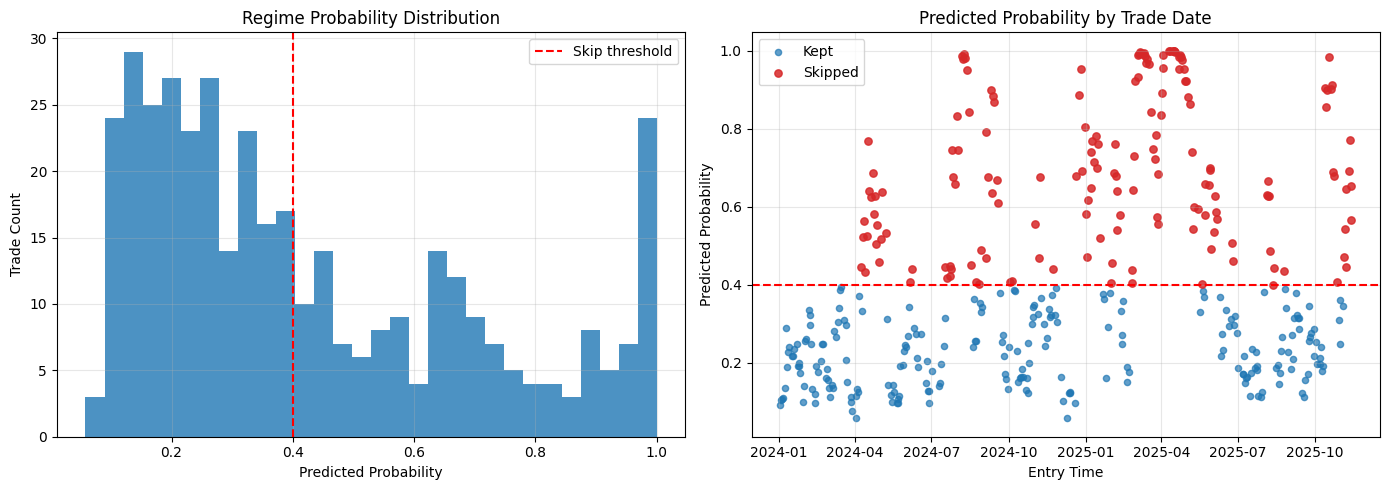

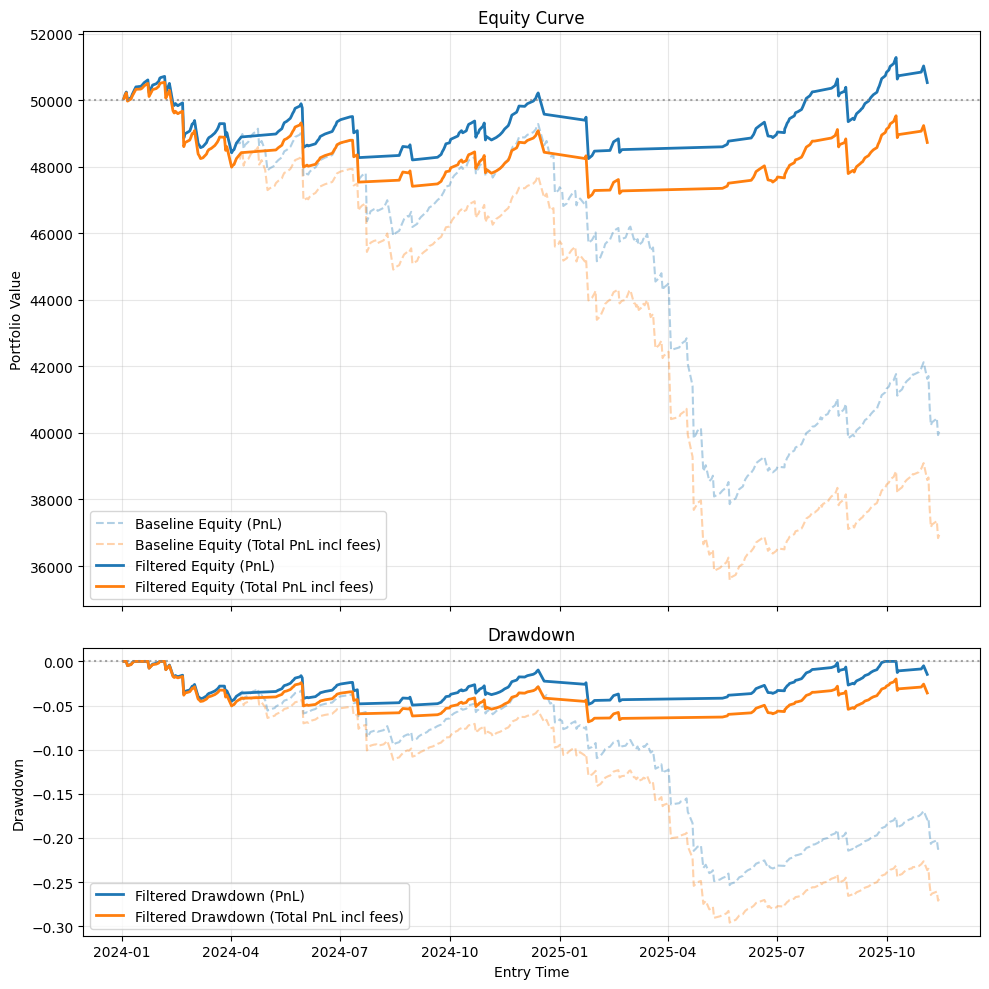

In [82]:
plot_probability_distribution(valid_trades)

fig, axs = plot_equity_and_drawdown(filtered_curve, baseline_curve, initial_capital=INITIAL_CAPITAL)

plt.savefig('equity_drawdown_spx_regime_filter.png')

plt.tight_layout()
plt.show()

## Regime Classification Performance

             Pred Low  Pred High
Actual Low        161         50
Actual High        64        113

              precision    recall  f1-score   support

   low_range       0.72      0.76      0.74       211
  high_range       0.69      0.64      0.66       177

    accuracy                           0.71       388
   macro avg       0.70      0.70      0.70       388
weighted avg       0.71      0.71      0.70       388



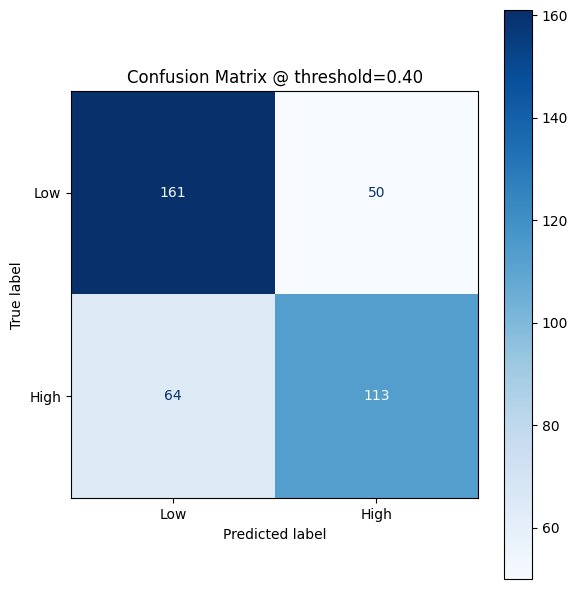

In [83]:
spx = spx_day.copy().sort_values("date").reset_index(drop=True)
spx["range"] = spx["high"] - spx["low"]
spx["next_day_range"] = spx["range"].shift(-1)
spx["actual_high_regime"] = spx["next_day_range"] >= REGIME_THRESHOLD
trade_features_with_actuals = trade_features.merge(spx[["date", "next_day_range", "actual_high_regime"]], on="date", how="left")

eval_df = trade_features_with_actuals.dropna(subset=["regime_prob", "actual_high_regime"]).copy()

y_true = eval_df["actual_high_regime"].astype(int)
y_pred = (eval_df["regime_prob"] >= SKIP_PROB_THRESHOLD).astype(int)
eval_df["pred_high_regime"] = y_pred.astype(bool)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual High"],
    columns=["Pred Low", "Pred High"],
)

print(cm_df)
print()
print(classification_report(y_true, y_pred, target_names=["low_range", "high_range"]))

y_true = eval_df["actual_high_regime"].astype(int)
y_pred = (eval_df["regime_prob"] >= SKIP_PROB_THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, y_pred),
    display_labels=["Low", "High"],
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix @ threshold={SKIP_PROB_THRESHOLD:.2f}")

plt.savefig('spx_regime_cm.png')

plt.tight_layout()
plt.show()

## Trade Performance by Predicted Regime Probability

In [84]:
bucket_expectancy = valid_trades[["regime_prob", "total_pnl"]].copy()

bucket_expectancy["probability_bucket"] = pd.cut(
    bucket_expectancy["regime_prob"],
    bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"],
    include_lowest=True,
    right=True,
)

bucket_expectancy["expectancy"] = bucket_expectancy["total_pnl"]

bucket_summary = (
    bucket_expectancy.groupby("probability_bucket", observed=False)
    .agg(
        trade_count=("total_pnl", "size"),
        expectancy=("expectancy", "mean"),
    )
    .reset_index()
)

bucket_summary

,probability_bucket,trade_count,expectancy
0,0.0-0.2,100,-14.350000
1,0.2-0.4,125,1.320000
2,0.4-0.6,59,-41.728814
3,0.6-0.8,52,-40.788462
4,0.8-1.0,52,-138.673077
